In [1]:
import cv2


In [2]:
import numpy as np
import pandas as pd

In [3]:
df_train = r"C:\Users\ASHWARY MAN\OneDrive\Desktop\Grape-Disease\train"
df_val = r"C:\Users\ASHWARY MAN\OneDrive\Desktop\Grape-Disease\val"

In [4]:
import os

In [5]:
def create_dataframe(path):

    image_paths = []
    labels = []

    for class_name in os.listdir(path):

        class_folder = os.path.join(path, class_name)

        if os.path.isdir(class_folder):

            for image in os.listdir(class_folder):

                image_paths.append(os.path.join(class_folder, image))
                labels.append(class_name)

    df = pd.DataFrame({
        "Image_Path": image_paths,
        "Label": labels
    })

    return df

In [6]:
train_df = create_dataframe(df_train)
val_df = create_dataframe(df_val)

In [7]:
train_df.head(5)

,Image_Path,Label
0,C:\Users\ASHWARY MAN\OneDrive\Desktop\Grape-Di...,Grape___Black_rot
1,C:\Users\ASHWARY MAN\OneDrive\Desktop\Grape-Di...,Grape___Black_rot
2,C:\Users\ASHWARY MAN\OneDrive\Desktop\Grape-Di...,Grape___Black_rot
3,C:\Users\ASHWARY MAN\OneDrive\Desktop\Grape-Di...,Grape___Black_rot
4,C:\Users\ASHWARY MAN\OneDrive\Desktop\Grape-Di...,Grape___Black_rot


In [8]:
val_df.tail(5)

,Image_Path,Label
806,C:\Users\ASHWARY MAN\OneDrive\Desktop\Grape-Di...,Grape___Leaf_blight_(Isariopsis_Leaf_Spot)
807,C:\Users\ASHWARY MAN\OneDrive\Desktop\Grape-Di...,Grape___Leaf_blight_(Isariopsis_Leaf_Spot)
808,C:\Users\ASHWARY MAN\OneDrive\Desktop\Grape-Di...,Grape___Leaf_blight_(Isariopsis_Leaf_Spot)
809,C:\Users\ASHWARY MAN\OneDrive\Desktop\Grape-Di...,Grape___Leaf_blight_(Isariopsis_Leaf_Spot)
810,C:\Users\ASHWARY MAN\OneDrive\Desktop\Grape-Di...,Grape___Leaf_blight_(Isariopsis_Leaf_Spot)


In [9]:
train_df["Label"].value_counts()

Label
Grape___Esca_(Black_Measles)                  1107
Grape___Black_rot                              942
Grape___Leaf_blight_(Isariopsis_Leaf_Spot)     861
Grape___healthy                                339
Name: count, dtype: int64

In [10]:
from sklearn.preprocessing import LabelEncoder

In [11]:
le = LabelEncoder()

In [12]:
train_df["Encoded"] = le.fit_transform(train_df["Label"])
val_df["Encoded"] = le.transform(val_df["Label"])

In [13]:
 print(le.classes_)

['Grape___Black_rot' 'Grape___Esca_(Black_Measles)'
 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)' 'Grape___healthy']


In [14]:
train_df

,Image_Path,Label,Encoded
0,C:\Users\ASHWARY MAN\OneDrive\Desktop\Grape-Di...,Grape___Black_rot,0
1,C:\Users\ASHWARY MAN\OneDrive\Desktop\Grape-Di...,Grape___Black_rot,0
2,C:\Users\ASHWARY MAN\OneDrive\Desktop\Grape-Di...,Grape___Black_rot,0
3,C:\Users\ASHWARY MAN\OneDrive\Desktop\Grape-Di...,Grape___Black_rot,0
4,C:\Users\ASHWARY MAN\OneDrive\Desktop\Grape-Di...,Grape___Black_rot,0
...,...,...,...
3244,C:\Users\ASHWARY MAN\OneDrive\Desktop\Grape-Di...,Grape___Leaf_blight_(Isariopsis_Leaf_Spot),2
3245,C:\Users\ASHWARY MAN\OneDrive\Desktop\Grape-Di...,Grape___Leaf_blight_(Isariopsis_Leaf_Spot),2
3246,C:\Users\ASHWARY MAN\OneDrive\Desktop\Grape-Di...,Grape___Leaf_blight_(Isariopsis_Leaf_Spot),2
3247,C:\Users\ASHWARY MAN\OneDrive\Desktop\Grape-Di...,Grape___Leaf_blight_(Isariopsis_Leaf_Spot),2


In [15]:
IMG_SIZE = 224

def load_images(df):

    images = []
    labels = []

    for _, row in df.iterrows():

        img = cv2.imread(row["Image_Path"])

        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))

        images.append(img)

        labels.append(row["Encoded"])

    X = np.array(images, dtype=np.float32)

    y = np.array(labels)

    return X, y

In [16]:
X_train, y_train = load_images(train_df)
X_val, y_val = load_images(val_df)

In [17]:
X_train.shape

(3249, 224, 224, 3)

In [18]:
y_train.shape

(3249,)

In [19]:
X_val.shape

(811, 224, 224, 3)

In [20]:
y_val.shape

(811,)

NameError: name 'plt' is not defined

In [22]:
X_train = X_train/255.0
X_val = X_val/255.0

In [23]:
np.unique(y_train)

array([0, 1, 2, 3])

In [24]:
np.unique(y_val)

array([0, 1, 2, 3])

In [25]:
np.save("data/X_train.npy",X_train)
np.save("data/y_train.npy",y_train)
np.save("data/X_val.npy",X_val)
np.save("data/y_val.npy",y_val)

In [26]:
train_df["Label"].value_counts()

Label
Grape___Esca_(Black_Measles)                  1107
Grape___Black_rot                              942
Grape___Leaf_blight_(Isariopsis_Leaf_Spot)     861
Grape___healthy                                339
Name: count, dtype: int64

In [27]:
import pickle
with open("data/label_encoder.pkl","wb") as f:
    pickle.dump(le, f)

In [28]:
val_df["Label"].value_counts()

Label
Grape___Esca_(Black_Measles)                  276
Grape___Black_rot                             236
Grape___Leaf_blight_(Isariopsis_Leaf_Spot)    215
Grape___healthy                                84
Name: count, dtype: int64

In [29]:
X_train.dtype

dtype('float32')

In [30]:
X_train.min(),X_train.max()

(np.float32(0.0), np.float32(1.0))

In [31]:
X_train.shape

(3249, 224, 224, 3)

In [32]:
import matplotlib.pyplot as plt

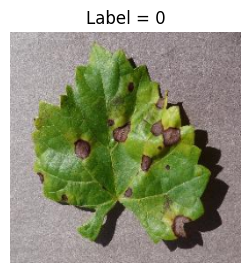

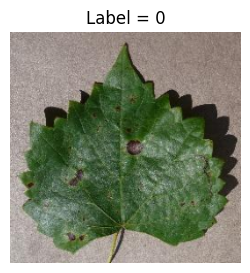

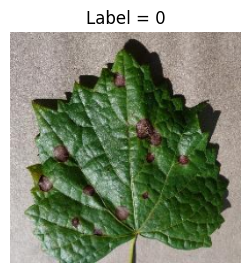

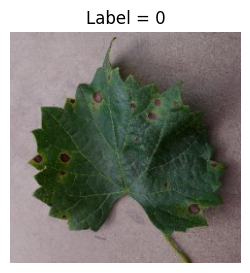

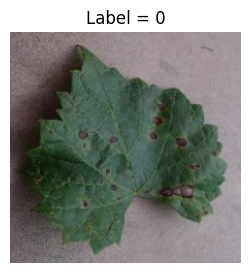

In [33]:
for i in range(5):
    plt.figure(figsize=(3,3))
    plt.imshow(X_train[i])
    plt.title(f"Label = {y_train[i]}")
    plt.axis("off")
    plt.show()